In [2]:
import math
import cv2
import numpy as np
import gymnasium as gym

from time import sleep
from gymnasium import spaces
from collections import Counter

from typing import Dict, Any, Sequence, Tuple, Optional

from importnb import Notebook
with Notebook():
    from LabTrajectory import simulate_viewport_with_tiles
    from LabLatencyModel import LatencyModel
    from LabCacheEngine import CacheEngineEnv
    from LabUserTileRequest import UserTileRequestEvents

import sys
sys.path.append(r'c:\Users\es25591\Workspace\CacheVideoPredict360\Sources')

from Common.Utils import zipf

In [3]:
def previousTilePrefetcher(step, i, users_viewport_tiles, n) -> np.ndarray:
    step -= 1

    action = np.zeros(n*n, dtype=int)
    
    if step < 0: return action
    
    for tile in users_viewport_tiles[i][step]:
        tx, ty = tile[0], tile[1]
        if 0 > tx or tx >= n or 0 > ty or ty >= n:
            continue
        action[tx * n + ty] = 1
    return action

In [4]:
class EnvWrapper(gym.Env):
    """
    Simple wrapper that delegates all calls to an inner env.
    Subclass this to create your own wrappers.
    """

    def __init__(
        self, 
        n: int,
        n_layers: int,
        users_env: None,
        cache_env: None,
        latency_model: LatencyModel, 
        fetch_request_callable=None
    ):
        super().__init__()

        self.n = n  # number of tiles per row/column
        self.n_layers = n_layers  # number of layers (base + enhancement)
        
        self.gain_if_prefetched = 1.0
        self.loss_if_not_prefetched = -1.0

        self.theta = 0.5
        self.lam = 3.7183

        self.users_env = users_env
        self.cache_env = cache_env
        self.latency_model = latency_model
        self.fetch_request_callable = fetch_request_callable

    def step(self, action):
        reward = 0.0
        info = {}

        ### STEP 1: prefetching segments in the cache based on action taken by agent ###
        by_video = self.cache_env.process_cache_prefetching(action)

        # print("Complete cache matrix by_video:")
        # print(f"Shape: {by_video.shape}")
        # for vid_idx in range(by_video.shape[0]):
        #     print(f"\nVideo {vid_idx}:")
        #     for layer_idx in range(by_video.shape[1]):
        #         print(f"  Layer {layer_idx}: {by_video[vid_idx, layer_idx]}")

        ### STEP 2: Generate user requests ###
        reqs = self.users_env.step(by_video)
        # print("User requests:", reqs)

        ### STEP 3: compute latencies for each request ###
        total_latency = 0.0
        for req in reqs:
            p = req.get("p", 0)
            u = req.get("u", 0)
            tiles = req.get("tiles", [])
            
            req_latency, tile_latencies = self.latency_model.total_request_latency(
                p, 
                u, 
                tiles
            )
            
            total_latency += req_latency
            # print(
            #     f"User {u}, DU {p}, total latency: {req_latency:.4f}s, tiles requested: {len(tiles)}, tiles received: {len(tile_latencies)}"
            # )            
        
        ### STEP 4: Calculate metrics: cache hits and misses, and reward ###
        cache_hits = 0
        cache_misses = 0
        for req in reqs:
            vid = req['video']
            tiles = req['tiles']
            # print(f"Request for video {vid} with tiles: {tiles}")

            for tile in tiles:
                tile_idx = tile['tile']
                layer = tile['layer']

                if by_video[vid][layer][tile_idx] >= 1:
                    cache_hits += 1
                else:
                    cache_misses += 1

        info['cache_hits'] = int(cache_hits)
        info['cache_misses'] = int(cache_misses)

        # compute reward for this video's action and add
        total_requests = sum(len(req.get('tiles', [])) for req in reqs)
        
        # Compute current_p: probability for each (vid, tile_idx) based on requests
        tile_counts = {}
        for req in reqs:
            vid = req["video"]
            tiles = req["tiles"]
            for tile in tiles:
                key = (vid, tile['layer'], tile['tile'])
                tile_counts[key] = tile_counts.get(key, 0) + 1

        # Normalize by total_requests to get probabilities
        current_p = {
            key: count / total_requests
            for key, count in tile_counts.items()
        }
    
        reward += self.compute_expected_cpt_reward(
            prefetched_tiles=by_video,
            current_p=current_p,
            requests=reqs
        )

        return {}, reward, False, info

    def compute_expected_cpt_reward(self, prefetched_tiles, current_p, requests) -> float:
        expected_reward = 0.0
        requested_tile_keys = set()
        for request in requests:
            vid = request['video']
            tiles = request['tiles']

            for tile in tiles:
                layer = tile['layer']
                tile_idx = tile['tile']
                tile_key = (vid, layer, tile_idx)
                
                p = float(current_p.get(tile_key, 0.0))
                w = self.prelec_w(p, theta=self.theta)
                
                if prefetched_tiles[vid][layer][tile_idx] >= 1:
                    expected_outcome = self.gain_if_prefetched
                    requested_tile_keys.add(tile_key)
                else:
                    expected_outcome = self.loss_if_not_prefetched
                
                v = self.cpt_value(expected_outcome, lam=self.lam)
                expected_reward += w * v

        return float(expected_reward)

    def prelec_w(self, p: float, theta: float = 0.65) -> float:
        if p <= 0.0: return 0.0
        if p >= 1.0: return 1.0
        return math.exp(-((-math.log(p)) ** theta))

    def cpt_value(
        self,
        x: float, 
        lam: float = 1.5
    ) -> float:
        if x >= 0:
            return x
        else:
            return -lam * (-x)

    def reset(self, **kwargs):
        return self.env.reset(**kwargs)

    def render(self, mode="human"):
        return self.env.render(mode)

In [5]:
if __name__ == "__main__":
    n_episodes = 100
    n_steps = 60
    n_users = 30
    step_size = 5.0
    n_gops = 60
    n_layers = 2
    n_tiles = 4
    max_capacity = 50e6  # 50 MB
    total_videos = 100

    users_viewport_tiles = []
    for _ in range(n_users):
        _, _, viewport_tiles, _ = simulate_viewport_with_tiles(
            num_steps=n_gops,
            n=n_tiles,
            fov_yaw=90,
            fov_pitch=50,
            damping=0.99,
            step_size=5.0,
            start_yaw=180,
            start_pitch=0
        )

        users_viewport_tiles.append(viewport_tiles)
    
    requested_videos = zipf(n_users, total_videos=total_videos, alpha=1.0)
    requested_videos = [int(v-1) for v in requested_videos]

    users_env = UserTileRequestEvents(
        n_users=n_users,
        n_tiles=n_tiles*n_tiles,
        n_layers=n_layers,
        users_viewport_tiles=users_viewport_tiles,
        requested_videos=requested_videos
    )

    cache_env = CacheEngineEnv(
        n_tiles=n_tiles*n_tiles,
        n_videos=total_videos,
        cache_capacity=max_capacity,
    )

    # Create latency model (replace numbers with your real config)
    P = 1; U = n_users
    lat_model = LatencyModel(
        P=P, 
        U=U,
        R_M_D=80e6,       # 640 Mbps -> 80e6 B/s 
        R_C_M=1.25e9,     # 10 Gbps -> 1.25e9 B/s
        mu=2e7, 
        eta=2e5,
        B_pu_matrix=np.full((P, U), 40e6, dtype=float),    # 320 Mbps -> 40e6 B/s
        gamma_pu_matrix=np.full((P, U), 5.0, dtype=float), # SNRs
        rhoT_p=[0.2], 
        lambda_p=[0.05],
        du_fixed_delay=0.001,    # 1 ms
        mec_fixed_delay=0.005,   # 5 ms
        cloud_fixed_delay=0.05   # 50 ms
    )

    env = EnvWrapper(
        n=n_tiles,
        n_layers=n_layers,
        users_env=users_env, 
        cache_env=cache_env, 
        latency_model=lat_model
    )

    print(
        f"Experiment ===================\n"
        f"Total users: {n_users}\n"
        f"Videos requested: {requested_videos}\n"
        f"Cache capacity: {max_capacity}MB\n"
        f"Video matrix: {total_videos}x{n_layers}x{n_tiles*n_tiles}\n"
        f"==============================\n"
    )

    total_reward = 0.0
    for step in range(n_steps):
        actions = [
            {
                'user': i,
                'video': requested_videos[i],
                'tiles': previousTilePrefetcher(step, i, users_viewport_tiles, n_tiles)
            } for i in range(n_users)
        ]

        obs, reward, _, info = env.step(actions)

        total_reward += float(reward)

Experiment ===================
Total users: 30
Videos requested: [67, 70, 77, 93, 46, 2, 50, 31, 95, 6, 86, 80, 87, 17, 80, 60, 31, 82, 80, 77, 91, 95, 51, 47, 77, 59, 88, 34, 13, 70]
Cache capacity: 50000000.0MB
Video matrix: 100x2x16



In [6]:
def run_episodes(
    n_episodes,
    n_steps,
    total_videos,
    max_capacity, 
    n_users,
    step_size,
    n_gops,
    n_layers,
    n
):
    episode_rewards = []
    episode_lengths = []
    episode_cache_hits = []
    episode_cache_misses = []

    for ep in range(n_episodes):

        users_viewport_tiles = []
        for _ in range(n_users):
            _, _, viewport_tiles, _ = simulate_viewport_with_tiles(
                num_steps=n_gops,
                n=n,
                fov_yaw=90,
                fov_pitch=50,
                damping=0.99,
                step_size=step_size,
                start_yaw=180,
                start_pitch=0
            )

            users_viewport_tiles.append(viewport_tiles)
        
        requested_videos = zipf(n_users, total_videos=total_videos, alpha=1.0)
        requested_videos = [int(v-1) for v in requested_videos]

        users_env = UserTileRequestEvents(
            n_users=n_users,
            n_tiles=n*n,
            n_layers=n_layers,
            users_viewport_tiles=users_viewport_tiles,
            requested_videos=requested_videos
        )

        cache_env = CacheEngineEnv(
            n_tiles=n*n,
            n_videos=total_videos,
            cache_capacity=max_capacity,
        )

        P = 1; U = n_users
        lat_model = LatencyModel(
            P=P, 
            U=U,
            R_M_D=80e6,       # 640 Mbps -> 80e6 B/s 
            R_C_M=1.25e9,     # 10 Gbps -> 1.25e9 B/s
            mu=2e7, 
            eta=2e5,
            B_pu_matrix=np.full((P, U), 40e6, dtype=float),    # 320 Mbps -> 40e6 B/s
            gamma_pu_matrix=np.full((P, U), 5.0, dtype=float), # SNRs
            rhoT_p=[0.2], 
            lambda_p=[0.05],
            du_fixed_delay=0.001,    # 1 ms
            mec_fixed_delay=0.005,   # 5 ms
            cloud_fixed_delay=0.05   # 50 ms
        )

        env = EnvWrapper(
            n=n,
            n_layers=n_layers,
            users_env=users_env, 
            cache_env=cache_env, 
            latency_model=lat_model
        )

        total_reward = 0.0
        cache_hits = 0
        cache_misses = 0
    
        for step in range(n_steps):
            actions = [
                {
                    'user': i,
                    'video': requested_videos[i],
                    'tiles': previousTilePrefetcher(step, i, users_viewport_tiles, n)
                } for i in range(n_users)
            ]

            _, reward, _, info = env.step(actions)
            total_reward += float(reward)

            cache_hits += info.get('cache_hits', 0)
            cache_misses += info.get('cache_misses', 0)

        episode_lengths.append(n_steps)
        episode_rewards.append(total_reward)

        episode_cache_hits.append(int(cache_hits))
        episode_cache_misses.append(int(cache_misses))

    stats = {
        "n_episodes": n_episodes,
        "mean_steps": float(np.mean(episode_lengths)),
        "std_steps": float(np.std(episode_lengths)),
        "mean_reward": float(np.mean(episode_rewards)),
        "std_reward": float(np.std(episode_rewards)),
        "episode_lengths": episode_lengths,
        "episode_rewards": episode_rewards,
        "mean_cache_hits": float(np.mean(episode_cache_hits)),
        "std_cache_hits": float(np.std(episode_cache_hits)),
        "mean_cache_misses": float(np.mean(episode_cache_misses)),
        "std_cache_misses": float(np.std(episode_cache_misses)),
    }

    return stats

Total Videos: 100, Capacity: 10000000.0, Mean reward: -12370.2373, Std reward: 546.8310
Total Videos: 100, Capacity: 20000000.0, Mean reward: -12071.7544, Std reward: 567.6046
Total Videos: 100, Capacity: 30000000.0, Mean reward: -11891.0400, Std reward: 516.4748
Total Videos: 100, Capacity: 40000000.0, Mean reward: -11762.7439, Std reward: 611.2652
Total Videos: 100, Capacity: 50000000.0, Mean reward: -11365.8223, Std reward: 497.0238
Total Videos: 100, Capacity: 60000000.0, Mean reward: -11140.4819, Std reward: 444.7780
Total Videos: 100, Capacity: 70000000.0, Mean reward: -10580.7692, Std reward: 390.8402
Total Videos: 100, Capacity: 80000000.0, Mean reward: -9587.7849, Std reward: 598.6668
Total Videos: 100, Capacity: 90000000.0, Mean reward: -7789.8478, Std reward: 1848.9967
Total Videos: 100, Capacity: 100000000.0, Mean reward: -5235.1925, Std reward: 2806.1336
Total Videos: 200, Capacity: 10000000.0, Mean reward: -11970.5635, Std reward: 530.7311
Total Videos: 200, Capacity: 200

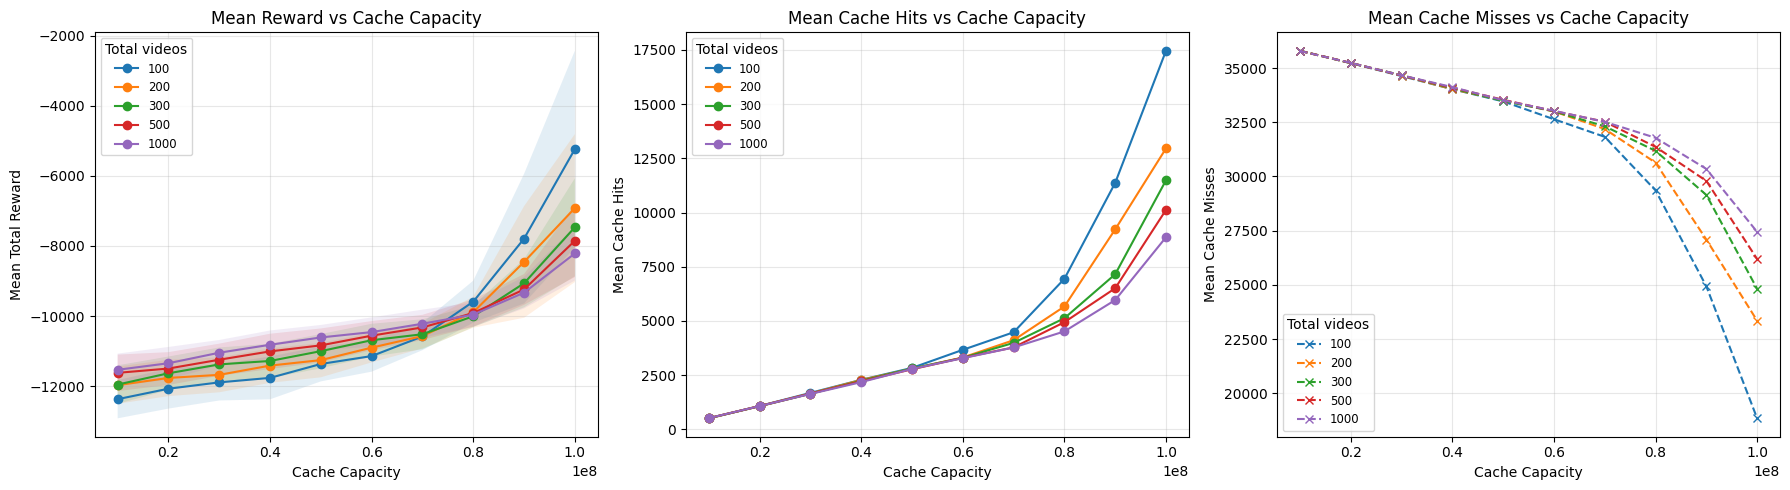

In [7]:
if __name__ == '__main__':
    capacities = [10e6, 20e6, 30e6, 40e6, 50e6, 60e6, 70e6, 80e6, 90e6, 100e6]
    total_videos_list = [100, 200, 300, 500, 1000]

    n_episodes = 100
    n_steps = 60
    n_users = 30
    step_size = 5.0
    n_gops = 60
    n_layers = 2
    n_tiles = 4
    
    # Store results for each total_videos
    results_by_videos = {}

    for total_videos in total_videos_list:
        capacity_results = {}
        for capacity in capacities:
            results = run_episodes(
                n_episodes=n_episodes,
                n_steps=n_steps,
                total_videos=total_videos,
                max_capacity=capacity,
                n_users=n_users,
                step_size=step_size,
                n_gops=n_gops,
                n_layers=n_layers,
                n=n_tiles
            )

            capacity_results[capacity] = results

            print(
                f"Total Videos: {total_videos}, Capacity: {capacity}, "
                f"Mean reward: {results['mean_reward']:.4f}, "
                f"Std reward: {results['std_reward']:.4f}"
            )

        # Store results for this total_videos
        results_by_videos[total_videos] = capacity_results

    # Plot the results
    import matplotlib.pyplot as plt
    caps = capacities

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)
    ax_reward, ax_hits, ax_misses = axes

    # Reward (mean ± std as shaded band)
    for total_videos in total_videos_list:
        means = [results_by_videos[total_videos][c]['mean_reward'] for c in caps]
        stds  = [results_by_videos[total_videos][c]['std_reward']  for c in caps]
        ax_reward.plot(caps, means, marker='o', label=f'{total_videos}')
        ax_reward.fill_between(caps,
                               np.array(means) - np.array(stds),
                               np.array(means) + np.array(stds),
                               alpha=0.12)
    ax_reward.set_xlabel('Cache Capacity')
    ax_reward.set_ylabel('Mean Total Reward')
    ax_reward.set_title('Mean Reward vs Cache Capacity')
    ax_reward.grid(alpha=0.3)
    ax_reward.legend(title='Total videos', fontsize='small')

    # Cache hits
    for total_videos in total_videos_list:
        cache_hits = [results_by_videos[total_videos][c]['mean_cache_hits'] for c in caps]
        ax_hits.plot(caps, cache_hits, marker='o', label=f'{total_videos}')
    ax_hits.set_xlabel('Cache Capacity')
    ax_hits.set_ylabel('Mean Cache Hits')
    ax_hits.set_title('Mean Cache Hits vs Cache Capacity')
    ax_hits.grid(alpha=0.3)
    ax_hits.legend(title='Total videos', fontsize='small')

    # Cache misses
    for total_videos in total_videos_list:
        cache_misses = [results_by_videos[total_videos][c]['mean_cache_misses'] for c in caps]
        ax_misses.plot(caps, cache_misses, marker='x', linestyle='--', label=f'{total_videos}')
    ax_misses.set_xlabel('Cache Capacity')
    ax_misses.set_ylabel('Mean Cache Misses')
    ax_misses.set_title('Mean Cache Misses vs Cache Capacity')
    ax_misses.grid(alpha=0.3)
    ax_misses.legend(title='Total videos', fontsize='small')

    plt.tight_layout()
    plt.show()